# Notebook 5 — Model Evaluation

## Objetivo

Evaluar de forma **final, objetiva y reproducible** el modelo optimizado en el Notebook 4.

En esta etapa no se modifican hiperparámetros ni se vuelve a entrenar el modelo para mejorar resultados.

El flujo es:

```text
Notebook 4
    ↓
Random Forest optimizado
    ↓
Test Set aislado
    ↓
Métricas
    ↓
Matriz de confusión
    ↓
Classification Report
    ↓
Análisis de errores
    ↓
Predicciones + probabilidades
    ↓
Artefactos para las siguientes etapas
```

### Principio clave

El conjunto **Test** se utiliza únicamente para estimar cómo se comportará el modelo sobre datos no utilizados durante el entrenamiento y el tuning.

El objetivo no es demostrar que el modelo es perfecto, sino determinar si su comportamiento es suficientemente consistente para pasar a **serialización y despliegue**.

## 01. Librerías

Utilizamos las mismas librerías principales del proceso anterior para mantener la compatibilidad con el Compute de Azure Machine Learning.

No actualizamos paquetes ni modificamos el entorno.

Necesitamos:

- `pandas` y `numpy` para manipulación de datos.
- `joblib` para cargar el modelo serializado.
- `scikit-learn` para métricas y visualizaciones de evaluación.
- `matplotlib` para las gráficas.

In [1]:
# ==========================================
# 01. Librerías
# ==========================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Librerías cargadas correctamente.")
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("sklearn:", __import__("sklearn").__version__)

Librerías cargadas correctamente.
numpy: 1.23.5
pandas: 1.5.3
sklearn: 1.5.1


## 02. Configuración

Reutilizamos exactamente las rutas, variable objetivo y columnas excluidas utilizadas en el Notebook 4.

Esto es fundamental para garantizar que el modelo reciba las mismas variables con las que fue construido.

El modelo que evaluaremos es:

```text
../models/tuned_random_forest.pkl
```

Este archivo contiene el **Pipeline completo**, incluyendo el tratamiento de desbalance utilizado durante el entrenamiento.

In [2]:
# ==========================================
# 02. Configuración
# ==========================================

INPUT_PATH = "../data/output_data/featureengineering_files.parquet"
MODEL_PATH = "../models/tuned_random_forest.pkl"
OUTPUT_DIR = "../models"

os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.30

TARGET = "label_e"

REMOVE_COLUMNS = [
    "machineID",
    "dt_truncated",
    "datetime",
    "failure",
    "model",
    TARGET
]

METRICS_PATH = os.path.join(
    OUTPUT_DIR,
    "model_evaluation_metrics.csv"
)

REPORT_PATH = os.path.join(
    OUTPUT_DIR,
    "model_classification_report.csv"
)

CONFUSION_PATH = os.path.join(
    OUTPUT_DIR,
    "model_confusion_matrix.csv"
)

PREDICTIONS_PATH = os.path.join(
    OUTPUT_DIR,
    "model_test_predictions.csv"
)

print("Dataset:", INPUT_PATH)
print("Modelo:", MODEL_PATH)
print("Target:", TARGET)
print("Test size:", TEST_SIZE)

Dataset: ../data/output_data/featureengineering_files.parquet
Modelo: ../models/tuned_random_forest.pkl
Target: label_e
Test size: 0.3


## 03. Carga del dataset

Cargamos el mismo dataset de características utilizado durante el modelado y el tuning.

En esta etapa no realizamos nuevas transformaciones de variables. La preparación de características pertenece al Notebook 2.

In [3]:
# ==========================================
# 03. Carga del dataset
# ==========================================

data = pd.read_parquet(INPUT_PATH)

print("Dimensiones:", data.shape)
display(data.head())

Dimensiones: (73143, 42)


,machineID,dt_truncated,volt_rollingmean_12,volt_rollingstd_12,rotate_rollingmean_12,rotate_rollingstd_12,pressure_rollingmean_12,pressure_rollingstd_12,vibration_rollingmean_12,vibration_rollingstd_12,...,comp2sum,comp3sum,comp4sum,age,model_model1,model_model2,model_model3,model_model4,failure,label_e
0,1,2015-01-01 00:00:00,169.512597,6.239068,425.853115,46.581966,101.886267,13.166950,41.119335,4.473233,...,213.0,153.0,168.0,18,0,0,1,0,0.0,0.0
1,1,2015-01-01 12:00:00,167.007032,8.260186,434.948972,50.000568,100.970047,10.863588,39.412711,5.716674,...,214.0,154.0,169.0,18,0,0,1,0,0.0,4.0
2,1,2015-01-02 00:00:00,171.754734,13.479925,454.534311,44.925868,93.989345,7.963589,40.265190,5.761581,...,214.0,154.0,169.0,18,0,0,1,0,0.0,4.0
3,1,2015-01-02 12:00:00,168.184995,15.356860,444.596343,39.260749,100.778017,10.107193,39.209928,5.957205,...,215.0,155.0,170.0,18,0,0,1,0,0.0,4.0
4,1,2015-01-03 00:00:00,172.717240,12.879603,468.079805,40.727721,99.586915,12.005493,40.406556,5.574350,...,215.0,155.0,170.0,18,0,0,1,0,0.0,4.0


## 04. Reconstrucción de X / y

Separamos:

- `X`: variables predictoras.
- `y`: variable objetivo `label_e`.

Las columnas identificadoras, temporales y utilizadas para construir la etiqueta se excluyen.

La definición debe coincidir con el Notebook 4 para evitar diferencias entre entrenamiento y evaluación.

In [4]:
# ==========================================
# 04. X / y
# ==========================================

input_features = [
    col for col in data.columns
    if col not in REMOVE_COLUMNS
]

X = data[input_features].copy()
y = data[TARGET].copy()

print("Variable objetivo:", TARGET)
print("Variables predictoras:", len(input_features))
print("X:", X.shape)
print("y:", y.shape)
print("Clases:", sorted(y.unique()))

Variable objetivo: label_e
Variables predictoras: 38
X: (73143, 38)
y: (73143,)
Clases: [0.0, 1.0, 2.0, 3.0, 4.0]


## 05. Reconstrucción del Train / Test

Reconstruimos la misma partición utilizada anteriormente:

- **70 % Train**
- **30 % Test**
- `random_state = 42`
- `stratify = y`

Esto permite recuperar el mismo conjunto de prueba sin almacenar físicamente el split.

### Regla

El Test Set no se utiliza para:

- seleccionar hiperparámetros;
- entrenar el modelo;
- aplicar SMOTE;
- seleccionar nuevas variables.

Aquí solamente se utiliza para medir el desempeño final.

In [5]:
# ==========================================
# 05. Train / Test
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)
print()
print("Distribución Test:")
display(
    y_test.value_counts()
    .sort_index()
    .to_frame("Count")
)

Train: (51200, 38)
Test : (21943, 38)

Distribución Test:


,Count
0.0,20236
1.0,404
2.0,560
3.0,300
4.0,443


## 06. Carga del modelo optimizado

Cargamos el modelo generado en el Notebook 4.

No entrenamos nuevamente.

El objeto cargado corresponde al `best_estimator_` seleccionado durante `RandomizedSearchCV`.

Como el modelo se almacenó como Pipeline, las transformaciones necesarias quedan encapsuladas dentro del artefacto.

In [6]:
# ==========================================
# 06. Carga del modelo
# ==========================================

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(
        f"No se encontró el modelo: {MODEL_PATH}"
    )

model = joblib.load(MODEL_PATH)

print("Modelo cargado correctamente.")
print(type(model))

Modelo cargado correctamente.
<class 'imblearn.pipeline.Pipeline'>


## 07. Generación de predicciones

Generamos dos elementos:

- `predict()` → clase predicha.
- `predict_proba()` → probabilidad estimada para cada clase.

Las probabilidades serán especialmente importantes posteriormente para:

- análisis de confianza;
- aplicaciones;
- endpoints;
- Power BI;
- monitoreo;
- definición de umbrales de decisión.

El Test Set permanece sin modificar.

In [7]:
# ==========================================
# 07. Predicciones
# ==========================================

test_pred = model.predict(X_test)
test_prob = model.predict_proba(X_test)

print("Predicciones generadas.")
print("Número de predicciones:", len(test_pred))
print("Matriz de probabilidades:", test_prob.shape)

Predicciones generadas.
Número de predicciones: 21943
Matriz de probabilidades: (21943, 5)


## 08. Métricas finales

Evaluamos el modelo con las métricas definidas durante el proyecto:

| Métrica | Interpretación |
|---|---|
| Accuracy | Proporción total de predicciones correctas |
| Precision Macro | Precisión promedio dando igual peso a cada clase |
| Recall Macro | Capacidad promedio de detectar cada clase |
| F1 Macro | Balance entre Precision y Recall por clase |
| ROC-AUC Macro OVR | Capacidad promedio de separar las clases |

### Métrica principal

Utilizamos **F1 Macro** como métrica principal porque el problema presenta un fuerte desbalance de clases.

Esto evita que una clase mayoritaria domine artificialmente la evaluación.

In [8]:
# ==========================================
# 08. Métricas finales
# ==========================================

classes = np.sort(np.unique(y_test))

metrics = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision Macro": precision_score(
        y_test,
        test_pred,
        average="macro",
        zero_division=0
    ),
    "Recall Macro": recall_score(
        y_test,
        test_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Macro": f1_score(
        y_test,
        test_pred,
        average="macro",
        zero_division=0
    ),
    "ROC-AUC Macro OVR": roc_auc_score(
        y_test,
        test_prob,
        multi_class="ovr",
        average="macro"
    )
}

metrics_df = pd.DataFrame([metrics])

display(metrics_df.round(4))

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro,ROC-AUC Macro OVR
0,Tuned Random Forest,0.9417,0.7265,0.5449,0.6149,0.9119


## 09. Classification Report

Las métricas macro resumen el comportamiento global, pero no muestran qué ocurre con cada clase.

El `Classification Report` permite analizar:

- Precision por clase.
- Recall por clase.
- F1 por clase.
- Número de observaciones (`support`).

Esto es especialmente importante en mantenimiento predictivo porque un modelo puede tener un buen desempeño global y, simultáneamente, presentar dificultades para detectar determinados tipos de falla.

In [9]:
# ==========================================
# 09. Classification Report
# ==========================================

report_dict = classification_report(
    y_test,
    test_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df.round(4))

,precision,recall,f1-score,support
0.0,0.9557,0.9846,0.9699,20236.0000
1.0,0.5655,0.3738,0.4501,404.0000
2.0,0.7732,0.4321,0.5544,560.0000
3.0,0.6605,0.4733,0.5515,300.0000
4.0,0.6777,0.4605,0.5484,443.0000
accuracy,0.9417,0.9417,0.9417,0.9417
macro avg,0.7265,0.5449,0.6149,21943.0000
weighted avg,0.9342,0.9417,0.9355,21943.0000


## 10. Matriz de confusión

La matriz de confusión permite observar dónde se producen los errores.

- Filas → clase real.
- Columnas → clase predicha.
- Diagonal → predicciones correctas.
- Fuera de la diagonal → errores de clasificación.

En un problema multiclasificación, esta matriz permite identificar específicamente qué tipos de falla se están confundiendo entre sí.

,Pred_0.0,Pred_1.0,Pred_2.0,Pred_3.0,Pred_4.0
Real_0.0,19924,102,62,64,84
Real_1.0,248,151,1,3,1
Real_2.0,305,3,242,1,9
Real_3.0,150,1,4,142,3
Real_4.0,220,10,4,5,204


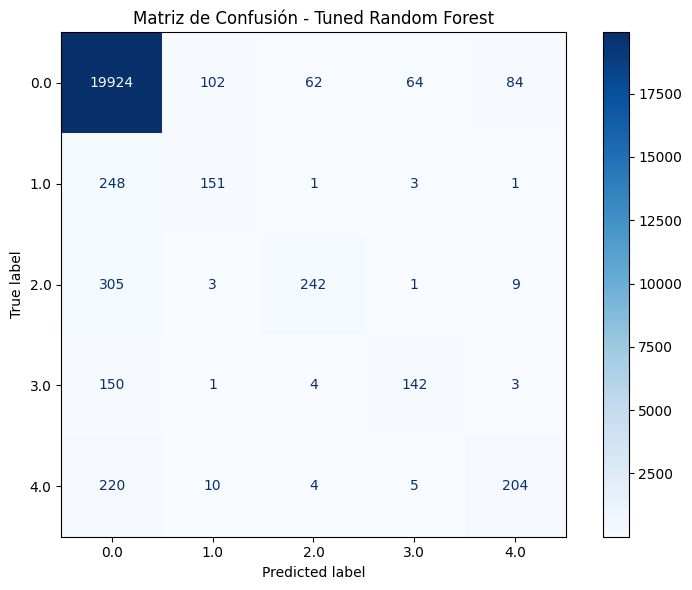

In [10]:
# ==========================================
# 10. Matriz de confusión
# ==========================================

cm = confusion_matrix(
    y_test,
    test_pred,
    labels=classes
)

cm_df = pd.DataFrame(
    cm,
    index=[f"Real_{c}" for c in classes],
    columns=[f"Pred_{c}" for c in classes]
)

display(cm_df)

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues",
    colorbar=True
)

ax.set_title("Matriz de Confusión - Tuned Random Forest")
plt.tight_layout()
plt.show()

## 11. Análisis de generalización

Una evaluación profesional no consiste únicamente en observar una métrica.

Comparamos:

```text
Train F1 Macro
       ↓
CV F1 Macro
       ↓
Test F1 Macro
```

Una diferencia muy grande entre Train y Test puede indicar sobreajuste.

También observamos la diferencia entre Cross Validation y Test.

### Interpretación

- **Train ≈ CV ≈ Test:** comportamiento consistente.
- **Train >> CV/Test:** posible sobreajuste.
- **CV ≈ Test:** buena evidencia de generalización.
- **CV >> Test:** el desempeño observado durante validación no se reproduce completamente en datos no vistos.

Estos valores son indicadores diagnósticos, no una prueba matemática absoluta de ausencia de overfitting.

In [11]:
# ==========================================
# 11. Generalización
# ==========================================

train_pred = model.predict(X_train)

train_f1_macro = f1_score(
    y_train,
    train_pred,
    average="macro",
    zero_division=0
)

test_f1_macro = metrics["F1 Macro"]

cv_f1_macro = np.nan

cv_path = "../models/tuned_random_forest_cv_confirmation.csv"

if os.path.exists(cv_path):
    cv_confirmation = pd.read_csv(cv_path)

    possible_cv_columns = [
        "CV F1 Macro Mean",
        "Best CV F1 Macro",
        "F1 Macro CV",
        "test_f1_macro"
    ]

    for column in possible_cv_columns:
        if column in cv_confirmation.columns:
            cv_f1_macro = cv_confirmation[column].iloc[0]
            break

if np.isnan(cv_f1_macro):
    tuning_path = "../models/random_forest_tuning_results.csv"

    if os.path.exists(tuning_path):
        tuning_results = pd.read_csv(tuning_path)

        possible_cv_columns = [
            "mean_test_score",
            "Best CV F1 Macro"
        ]

        for column in possible_cv_columns:
            if column in tuning_results.columns:
                cv_f1_macro = tuning_results[column].max()
                break

train_test_gap = train_f1_macro - test_f1_macro

if train_test_gap >= 0.10:
    status = "Posible señal de sobreajuste"
elif train_test_gap >= 0.05:
    status = "Brecha moderada"
else:
    status = "Sin señal fuerte"

generalization_df = pd.DataFrame([{
    "Train F1 Macro": train_f1_macro,
    "CV F1 Macro": cv_f1_macro,
    "Test F1 Macro": test_f1_macro,
    "Train-Test Gap": train_test_gap,
    "Status": status
}])

display(generalization_df.round(4))

,Train F1 Macro,CV F1 Macro,Test F1 Macro,Train-Test Gap,Status
0,0.9903,0.615,0.6149,0.3755,Posible señal de sobreajuste


## 12. Análisis de errores

Creamos una tabla de predicciones que permite analizar individualmente los casos:

- Clase real.
- Clase predicha.
- Si la predicción fue correcta.
- Probabilidad de la clase predicha.
- Probabilidades de todas las clases.

Esta tabla será además un artefacto útil para las siguientes etapas del proyecto y puede alimentar procesos de análisis o visualización.

In [12]:
# ==========================================
# 12. Análisis de errores
# ==========================================

predictions_df = X_test.copy()

predictions_df["y_true"] = y_test.values
predictions_df["y_pred"] = test_pred
predictions_df["correct"] = (
    predictions_df["y_true"] == predictions_df["y_pred"]
)

predicted_probability = test_prob.max(axis=1)

predictions_df["prediction_probability"] = predicted_probability

for i, class_label in enumerate(classes):
    predictions_df[f"prob_class_{class_label}"] = test_prob[:, i]

errors_df = predictions_df[
    predictions_df["correct"] == False
].copy()

print("Total predicciones:", len(predictions_df))
print("Correctas:", int(predictions_df["correct"].sum()))
print("Errores:", len(errors_df))
print(
    "Accuracy:",
    round(predictions_df["correct"].mean(), 4)
)

print()
print("Errores por clase real:")
display(
    errors_df["y_true"]
    .value_counts()
    .sort_index()
    .to_frame("Errors")
)

Total predicciones: 21943
Correctas: 20663
Errores: 1280
Accuracy: 0.9417

Errores por clase real:


,Errors
0.0,312
1.0,253
2.0,318
3.0,158
4.0,239


## 13. Casos de baja confianza

La probabilidad de la clase predicha permite identificar predicciones en las que el modelo presenta menor confianza.

Esto es útil para producción porque no todas las predicciones necesariamente deben tratarse de la misma manera.

Por ejemplo:

```text
Alta confianza
     ↓
Automatización

Baja confianza
     ↓
Revisión humana / alerta
```

El umbral de confianza mostrado aquí es únicamente ilustrativo. En un proyecto real debe definirse mediante validación y conocimiento del negocio.

In [13]:
# ==========================================
# 13. Baja confianza
# ==========================================

LOW_CONFIDENCE_THRESHOLD = 0.60

low_confidence_df = predictions_df[
    predictions_df["prediction_probability"]
    < LOW_CONFIDENCE_THRESHOLD
].copy()

print(
    f"Predicciones con probabilidad < "
    f"{LOW_CONFIDENCE_THRESHOLD:.0%}: "
    f"{len(low_confidence_df)}"
)

display(
    low_confidence_df[
        [
            "y_true",
            "y_pred",
            "prediction_probability"
        ]
    ].head(20)
)

Predicciones con probabilidad < 60%: 1819


,y_true,y_pred,prediction_probability
52979,0.0,0.0,0.508663
16348,0.0,0.0,0.593150
15884,2.0,2.0,0.508343
65832,0.0,0.0,0.353220
44670,4.0,4.0,0.544736
47105,0.0,0.0,0.582250
34233,2.0,0.0,0.487026
180,0.0,0.0,0.555889
68947,0.0,0.0,0.538880
4915,0.0,0.0,0.575365


## 14. Resumen ejecutivo de evaluación

Antes de pasar a producción debemos responder:

### ¿El modelo está listo para continuar?

La decisión debe considerar conjuntamente:

1. **Desempeño:** F1 Macro, Recall, Precision y ROC-AUC.
2. **Generalización:** comportamiento entre Train, CV y Test.
3. **Clases minoritarias:** desempeño individual por clase.
4. **Errores:** tipos de confusión observados.
5. **Confianza:** distribución de probabilidades.
6. **Trazabilidad:** existencia del modelo y métricas almacenadas.

El objetivo de esta etapa es obtener evidencia suficiente para pasar a **Model Serialization / Deployment**.

In [14]:
# ==========================================
# 14. Resumen ejecutivo
# ==========================================

print("==========================================")
print("RESUMEN DE EVALUACIÓN")
print("==========================================")
print(f"Modelo: Tuned Random Forest")
print(f"Accuracy       : {metrics['Accuracy']:.4f}")
print(f"Precision Macro: {metrics['Precision Macro']:.4f}")
print(f"Recall Macro   : {metrics['Recall Macro']:.4f}")
print(f"F1 Macro       : {metrics['F1 Macro']:.4f}")
print(f"ROC-AUC Macro  : {metrics['ROC-AUC Macro OVR']:.4f}")
print(f"Train F1 Macro : {train_f1_macro:.4f}")
print(f"Train-Test Gap : {train_test_gap:.4f}")
print(f"Status         : {status}")

RESUMEN DE EVALUACIÓN
Modelo: Tuned Random Forest
Accuracy       : 0.9417
Precision Macro: 0.7265
Recall Macro   : 0.5449
F1 Macro       : 0.6149
ROC-AUC Macro  : 0.9119
Train F1 Macro : 0.9903
Train-Test Gap : 0.3755
Status         : Posible señal de sobreajuste


## 15. Guardar artefactos

Guardamos los resultados de evaluación para mantener trazabilidad y permitir que otras etapas consuman estos resultados.

### Artefactos

```text
models/
├── tuned_random_forest.pkl
├── model_evaluation_metrics.csv
├── model_classification_report.csv
├── model_confusion_matrix.csv
└── model_test_predictions.csv
```

Las predicciones son especialmente importantes para las siguientes etapas, ya que permitirán demostrar el flujo:

```text
Modelo
  ↓
Predicciones
  ↓
Batch / Endpoint
  ↓
Persistencia
  ↓
Power BI
```

In [15]:
# ==========================================
# 15. Guardar artefactos
# ==========================================

metrics_df.to_csv(
    METRICS_PATH,
    index=False
)

report_df.to_csv(
    REPORT_PATH
)

cm_df.to_csv(
    CONFUSION_PATH
)

predictions_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

print("Artefactos guardados:")
print("-", METRICS_PATH)
print("-", REPORT_PATH)
print("-", CONFUSION_PATH)
print("-", PREDICTIONS_PATH)

Artefactos guardados:
- ../models/model_evaluation_metrics.csv
- ../models/model_classification_report.csv
- ../models/model_confusion_matrix.csv
- ../models/model_test_predictions.csv


# Resumen del Notebook 5

Al finalizar esta etapa tendremos:

```text
✓ Modelo optimizado cargado
✓ Test Set aislado
✓ Accuracy
✓ Precision Macro
✓ Recall Macro
✓ F1 Macro
✓ ROC-AUC Macro
✓ Classification Report
✓ Matriz de confusión
✓ Análisis de generalización
✓ Análisis de errores
✓ Predicciones
✓ Probabilidades
✓ Artefactos de evaluación
```

## Siguiente etapa

```text
05 Model Evaluation
        ↓
06 Model Serialization
        ↓
07 Deployment
        ↓
08 Batch Inference
        ↓
09 Monitoring
        ↓
Power BI / Aplicaciones
```

### Nota

Este notebook **no modifica el modelo**. Su función es producir evidencia de que el modelo optimizado puede pasar a la siguiente etapa del ciclo de vida.